In [4]:
from src.data_loader import load_data
from src.preprocess import prepare_data, print_vectorized_sample

from src.plotting import plot_confusion_matrix, plot_learning_curve, plot_metrics_bar_chart
from src.ML.train_svm import train_SVM
from src.ML.train_rf import train_random_forest

from src.LM.embeddings.embedder_preprocess import clean_text
from src.LM.embeddings.embedder_preprocess import load_word2vec_model
from src.LM.embeddings.embedder_preprocess import text_to_vector
from src.LM.embeddings.embedder_preprocess import prepare_data_word2vec

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

DATA_PATH = "/home/xkubanova_126831/bakalarka/nbs_binary/data/ekosentiment_titles_binary.csv"

In [5]:
print("--- 1. Loading and Preparing Data ---")
df = load_data(DATA_PATH)


#prepare data
X_train, X_test, y_train, y_test, w2vmodel = prepare_data_word2vec(df)


--- 1. Loading and Preparing Data ---
Dataset shape: (694, 2)

Categories samples:

0:
  Príjmy vedúcich policajných funkcionárov A verejnosť tak mohla o celkových príjmoch policajnej elity u nás iba špekulovať. Jeho príjem za vlaňajšok v celkovej výške takmer 44-tisíc eur totiž prekonal viceprezident polície Ľubomír Ábel. Príjmy vedúcich policajných funkcionárov...

1:
  Analytik o osobných bankrotoch: Ich pravidlá sú podľa neho nastavené veľmi voľne "Obávam sa, že toto nastavenie bude do budúcnosti motivovať časť ľudí, aby sa nadmerne zadlžovala a následne využila osobný bankrot a začala bez dlhov. "Od štátu by som čakal také nastavenie legislatívy, ktoré ľudí navedie k právnemu a finančnému poradenstvu a riešeniu dlhov v rannej fáze problému. Búlik z OVB je pres...
Loading pretrained Word2Vec model from gensim…
Model loaded



SUPPORT VECTOR MACHINE (SVM)

--- SVM Model Input Data Summary ---
X_train Shape (samples, features): (555, 300)
X_train Data Type: float32
y_train Shape (labels): (555,)
y_train Data Type: int64
Feature Vector Length (input_dim): 300
Matrix Format: <class 'numpy.ndarray'>
------------------------------
First sample (first 10 embedding values):
[-0.03783544  0.00454712  0.08998617  0.08576456  0.0216128   0.10295868
  0.04548137 -0.08522543 -0.04416911  0.06536356]
------------------------------

Computed class weights:
  0: 0.6869
  1: 1.8377

Best C found via StratifiedKFold: 0.5

--- SVM CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0     0.8228    0.6436    0.7222       101
           1     0.4000    0.6316    0.4898        38

    accuracy                         0.6403       139
   macro avg     0.6114    0.6376    0.6060       139
weighted avg     0.7072    0.6403    0.6587       139



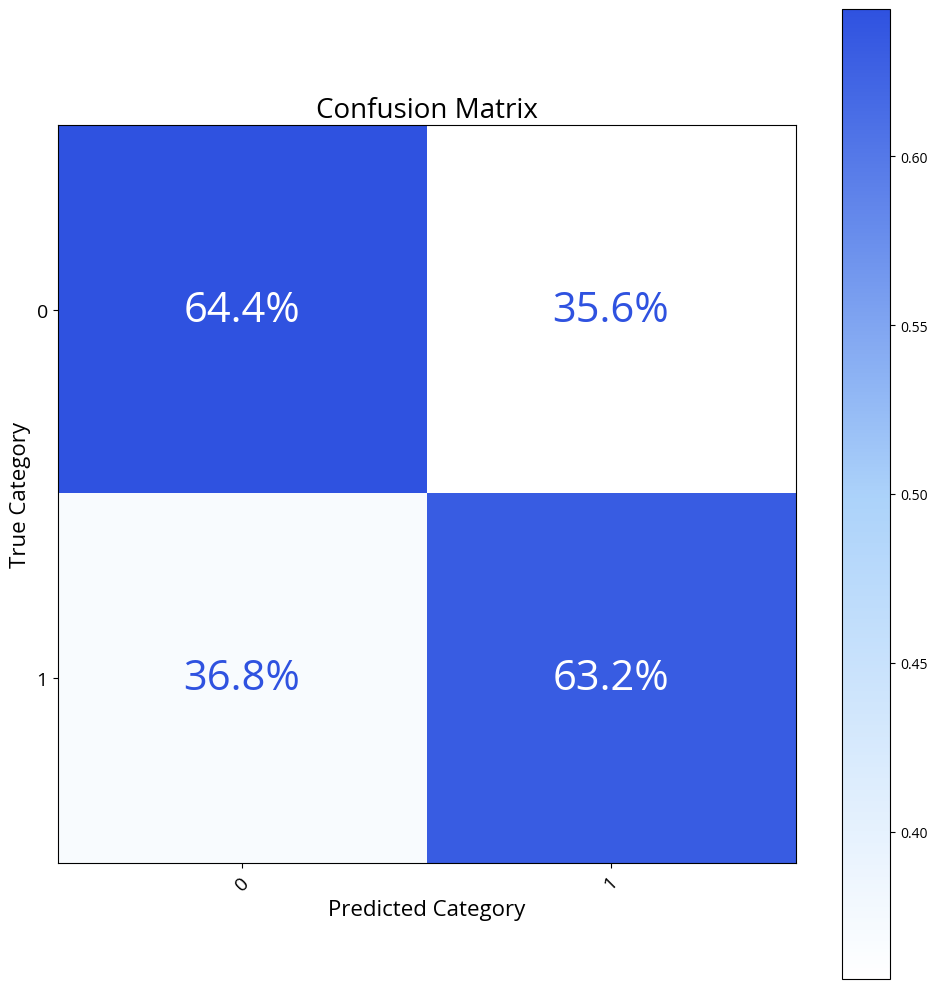

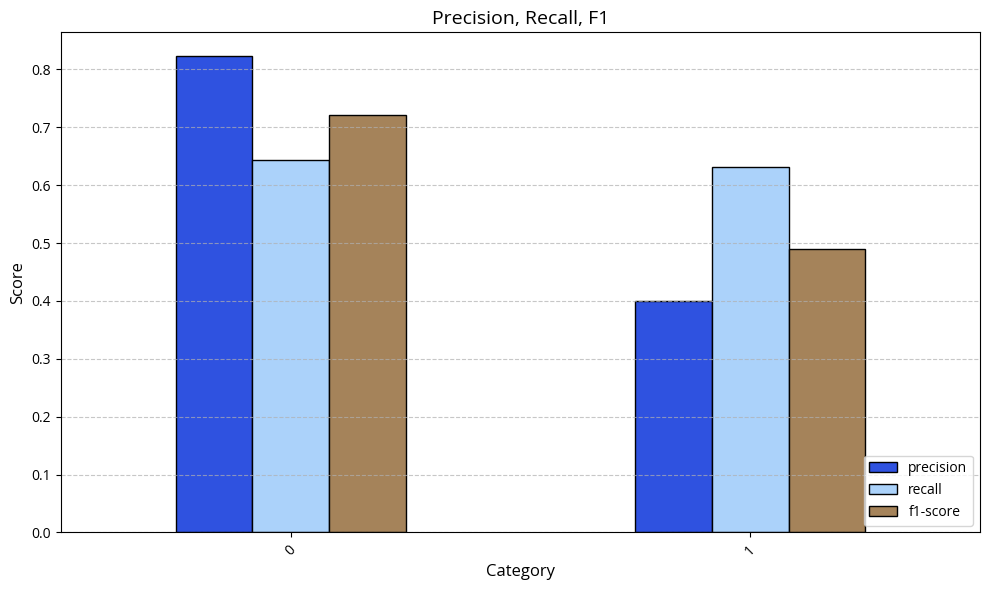

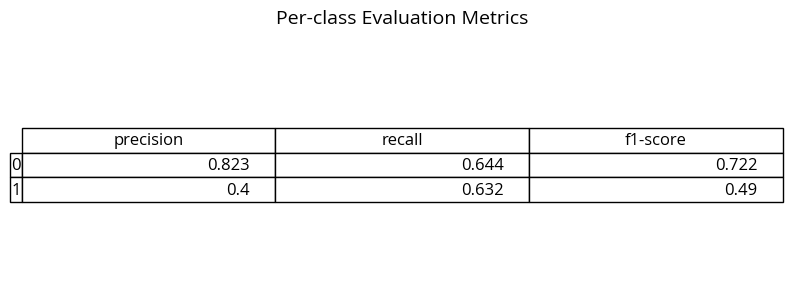

In [6]:
#SVM  - Word2Vec
target_names = [str(t) for t in sorted(y_train.unique())]
svm_model = train_SVM(X_train, y_train, X_test, y_test, target_names, boost_factor = 1.0)




RANDOM FOREST

--- RF Model Input Data Summary ---
X_train Shape (samples, features): (555, 300)
X_train Data Type: float32
y_train Shape (labels): (555,)
y_train Data Type: int64
Feature Vector Length (input_dim): 300
Matrix Format: <class 'numpy.ndarray'>
------------------------------
First sample (first 10 embedding values):
Prvá vzorka (prvých 10 TF-IDF hodnôt):
[-0.03783544  0.00454712  0.08998617  0.08576456  0.0216128   0.10295868
  0.04548137 -0.08522543 -0.04416911  0.06536356]
------------------------------
Original class weights: [0.68688119 1.83774834]
Boosted class weights: [0.68688119 1.83774834]
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best Random Forest parameters found via StratifiedKFold: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
              precision    recall  f1-score   support

           0     0.8519    0.6832    0.7582       101
           1     0.4483    0.6842    0.5417        38

    accu

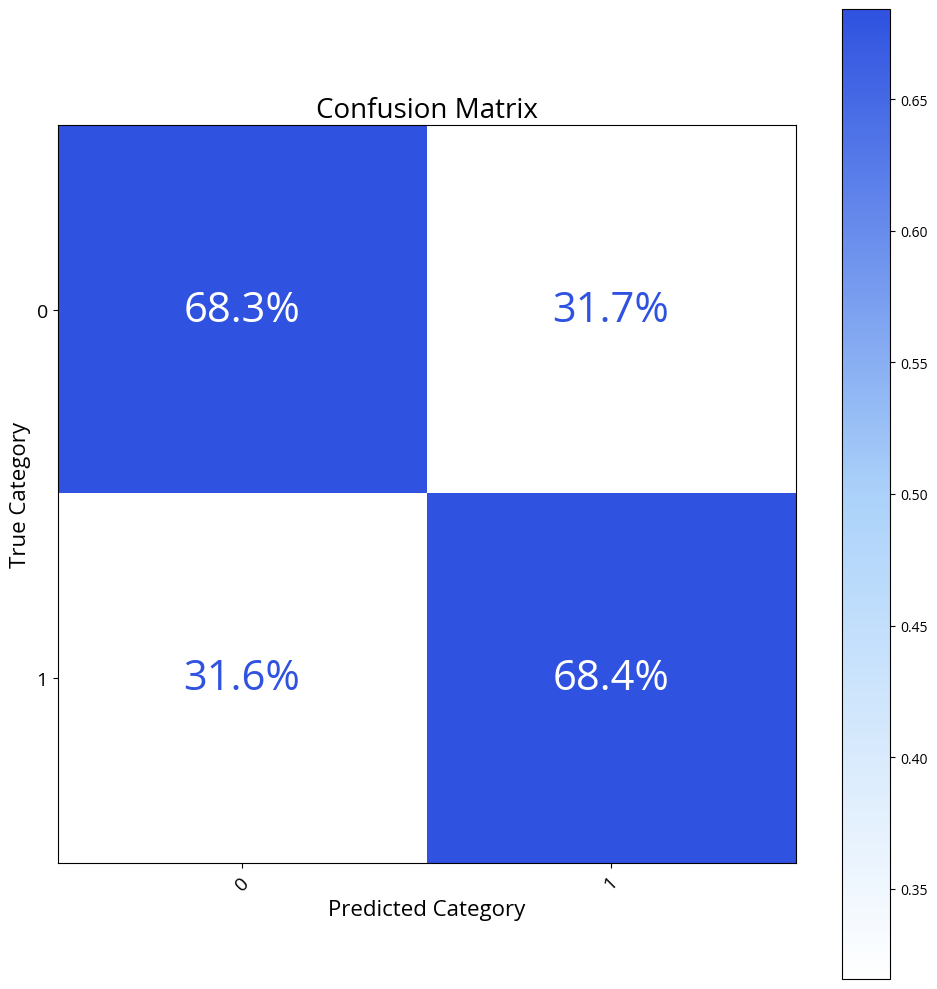

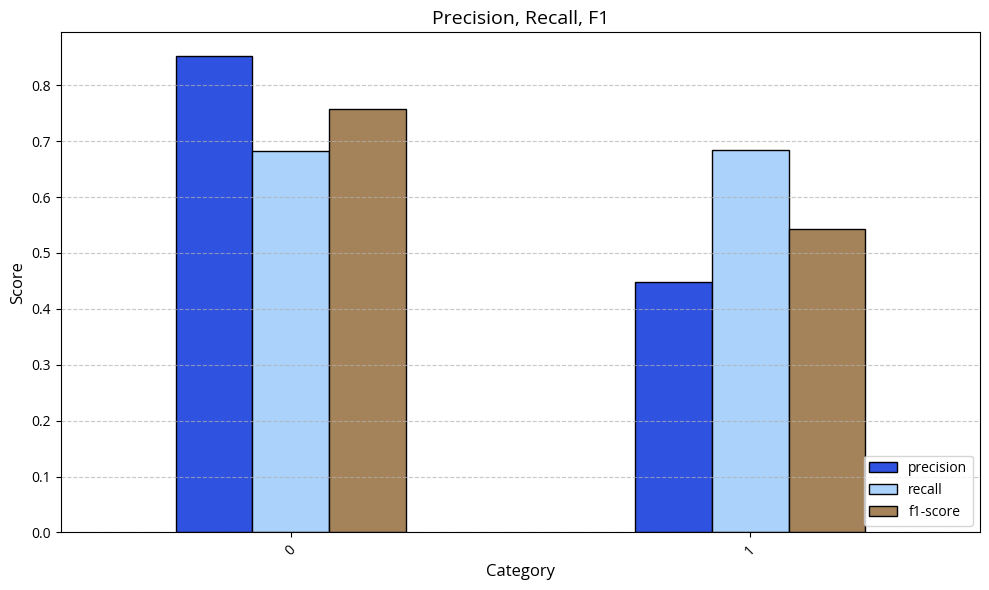

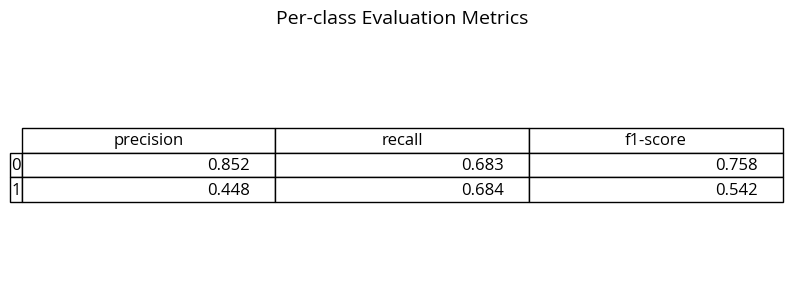

In [7]:
#Random Forest - Word2Vec
rf_model = train_random_forest(X_train, y_train, X_test, y_test, target_names)